# Clustering jerárquico (HC) sobre los embeddings del EDA

Se aplica **clustering jerárquico aglomerativo (Ward)** a cada una de las cinco
representaciones de embedding y se evalúa con **métricas de aprendizaje no supervisado**:

| Técnica | Representación usada para HC |
|---|---|
| TF-IDF | TruncatedSVD a 50 componentes (LSA) sobre la matriz sparse |
| MiniLM multilingüe | vectores densos de 384 dims |
| BGE-M3 (vLLM) | vectores densos de 1024 dims |
| BETO (chunking + pooling) | vectores densos de 768 dims |
| BETO whitened | los 768 dims anteriores, centrados y descorrelacionados a 128 |

Todos los vectores se **L2-normalizan** antes del linkage, de modo que la distancia
euclídea de Ward sea equivalente (monótona) a la distancia coseno — la métrica natural
para embeddings de texto.

Métricas calculadas para k = 2…15:
- **Silhouette** (↑ mejor, rango [-1, 1]) — cohesión vs. separación por punto.
- **Calinski-Harabasz** (↑ mejor) — razón de dispersión entre/intra clúster.
- **Davies-Bouldin** (↓ mejor) — similitud media entre cada clúster y su más parecido.
- **Correlación cofenética** (↑ mejor) — fidelidad del dendrograma a las distancias originales.

Además, una sección de **control de artefacto** mide si los clústeres separan por longitud
del artículo (η²) en lugar de por tema — relevante sobre todo para BETO, la única técnica
que procesa el artículo completo vía chunking.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

PALETA = ["#2a78d6", "#008300", "#e87ba4", "#c9761a", "#7b5ea7"]
sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.color": "#e1e0d9",
                     "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e"})
RANDOM_STATE = 42


def rejilla(n: int, ancho: float = 5.3, alto: float = 4.5, ncols: int = 3):
    """Rejilla de `n` paneles en `ncols` columnas; oculta los ejes sobrantes.

    Con cinco técnicas una sola fila haría figuras de ~27 pulgadas de ancho,
    ilegibles al renderizar; el envoltorio en filas mantiene el tamaño por panel.
    """
    nfilas = -(-n // ncols)
    fig, axes = plt.subplots(nfilas, ncols, figsize=(ancho * ncols, alto * nfilas))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]:
        ax.set_visible(False)
    return fig, axes[:n]


## Reproducción de la submuestra del EDA

Se replica exactamente la submuestra estratificada de ~1,500 artículos del EDA
(misma limpieza, mismos estratos año × periódico, mismo `random_state`) y se verifica
contra los `id_articulo` guardados en `data/embeddings/muestra_ids.npy` para garantizar
que los embeddings cacheados corresponden a estos textos.

In [2]:
import re
from math import ceil

data = pd.read_csv("../data/raw/stratified_sample_2019_2026.csv")
data.drop(columns=["anio", "id_pressreader", "id_periodico", "icor_index", "icor_v2_index"], inplace=True)
data["fecha"] = pd.to_datetime(data["fecha"])
data["anio"] = data["fecha"].dt.year


def norm_text(text: str) -> str:
    """Normaliza un texto: minúsculas y colapso de espacios en blanco."""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


data["texto_norm"] = data["texto"].map(norm_text)

N_MUESTRA = 1500
estratos = data.groupby(["nombre_periodico", "anio"])
cuota = ceil(N_MUESTRA / estratos.ngroups)
muestra = pd.concat(
    [g.sample(min(len(g), cuota), random_state=RANDOM_STATE) for _, g in estratos]
).sort_values(["anio", "nombre_periodico", "id_articulo"]).reset_index(drop=True)

textos_emb = (muestra["titulo"].fillna("").map(norm_text) + ". "
              + muestra["texto_norm"]).str.slice(0, 2000).tolist()

EMB_DIR = Path("../data/embeddings")
ids_muestra = muestra["id_articulo"].to_numpy()
assert np.array_equal(np.load(EMB_DIR / "muestra_ids.npy"), ids_muestra), \
    "La submuestra no coincide con la usada en el EDA: recalcular embeddings en eda.ipynb"
print(f"Submuestra reproducida: {len(muestra)} artículos — ids verificados contra el caché")


Submuestra reproducida: 1512 artículos — ids verificados contra el caché


## Carga de embeddings

MiniLM y BGE-M3 se cargan del caché generado por `eda.ipynb`; TF-IDF (que el EDA no
cachea por ser sparse) se recalcula con los mismos hiperparámetros y se reduce con
`TruncatedSVD` a 50 componentes, la misma reducción previa que el EDA usa para t-SNE.

**BETO** (`dccuchile/bert-base-spanish-wwm-cased`, 768 dims) se carga del caché que genera
`scripts/embed_beto.py`. A diferencia de las demás técnicas, no ve un texto truncado: cada
artículo se parte en ventanas solapadas de 512 tokens (el límite de contexto de BETO) y los
vectores de chunk se promedian (ver `src/embeddings/beto.py`).

Se probó *attention pooling* inter-chunk y se descartó por indistinguible de la media en
este corpus (coseno 0.9999, r = 0.9988 entre matrices de distancia): los artículos de
prensa apenas exceden la ventana de BETO — **mediana de 1 chunk, 65% en un solo chunk** —
así que el pooling casi nunca combina más de dos vectores.

In [3]:
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

vectorizador = TfidfVectorizer(max_features=50_000, min_df=3, max_df=0.6, sublinear_tf=True)
emb_tfidf_sparse = vectorizador.fit_transform(textos_emb)
emb_tfidf = TruncatedSVD(n_components=50, random_state=RANDOM_STATE).fit_transform(emb_tfidf_sparse)

emb_st = np.load(EMB_DIR / "minilm_multilingual.npy")
emb_bge = np.load(EMB_DIR / "bge_m3.npy")
emb_beto = np.load(EMB_DIR / "beto.npy")

# L2-normalización: euclídea sobre vectores unitarios ~ distancia coseno
embeddings = {
    "TF-IDF (SVD-50)": normalize(emb_tfidf),
    "MiniLM multilingüe": normalize(emb_st),
    "BGE-M3": normalize(emb_bge),
    "BETO": normalize(emb_beto),
}
for nombre, emb in embeddings.items():
    print(f"{nombre}: {emb.shape}")


TF-IDF (SVD-50): (1512, 50)
MiniLM multilingüe: (1512, 384)
BGE-M3: (1512, 1024)
BETO: (1512, 768)


### Whitening del espacio de BETO

BETO no tiene fine-tuning contrastivo, y su espacio es **anisotrópico**: todos los vectores
se concentran en un cono estrecho, con coseno medio de ~0.94 entre artículos tomados al azar
(economía vs. deportes deberían ser casi ortogonales). La causa es una **dirección común** a
todos los embeddings, heredada del preentrenamiento, que domina el producto punto y entierra
la señal temática. Como el silhouette es un cociente entre separación y dispersión, un rango
de distancias comprimido lo penaliza aunque la estructura exista.

El *whitening* (Su et al., 2021) corrige esto con una transformación lineal: centra los
vectores (elimina la dirección común) y aplica `W = Σ^(-1/2)`, dejando la covarianza en la
identidad — la nube pasa de cigarro alargado a esfera, y las direcciones de baja varianza,
donde viven las distinciones finas entre temas, se amplifican hasta pesar como las dominantes.

`Σ` se estima del propio corpus: con 1,512 documentos y 768 dimensiones hay menos muestras que
parámetros de covarianza, así que la estimación es ruidosa. Por eso se retienen solo
`N_COMP = 128` componentes (las de mayor varianza), que mitiga el ruido y actúa como el
*all-but-the-top* de Mu & Viswanath en su versión suave.

Se añade como técnica aparte para que la comparación con BETO sin whitening quede medida en
el mismo cuadro de métricas.

In [4]:
N_COMP = 128


def whitening(emb: np.ndarray, n_comp: int = N_COMP) -> np.ndarray:
    """Centra y descorrelaciona `emb`, reteniendo las `n_comp` direcciones de mayor varianza."""
    mu = emb.mean(axis=0)
    centrado = emb - mu
    # SVD de la covarianza: U son las direcciones principales, s sus varianzas.
    U, s, _ = np.linalg.svd(np.cov(centrado, rowvar=False))
    W = U[:, :n_comp] / np.sqrt(s[:n_comp])  # Sigma^(-1/2) truncada
    return centrado @ W


emb_beto_w = whitening(emb_beto)
embeddings["BETO (whitened)"] = normalize(emb_beto_w)

# Efecto sobre la anisotropia: coseno medio entre pares de documentos distintos.
for nombre in ("BETO", "BETO (whitened)"):
    X = embeddings[nombre]
    cos = (X @ X.T)[np.triu_indices(len(X), k=1)]
    print(f"{nombre}: coseno medio entre documentos = {cos.mean():.3f} "
          f"(desv. {cos.std():.3f}, rango [{cos.min():.2f}, {cos.max():.2f}])")


BETO: coseno medio entre documentos = 0.937 (desv. 0.029, rango [0.67, 0.99])
BETO (whitened): coseno medio entre documentos = -0.000 (desv. 0.087, rango [-0.38, 0.89])


## Linkage jerárquico (Ward) y dendrogramas

Se construye la jerarquía completa con `scipy.cluster.hierarchy.linkage(method="ward")`
y se reporta la **correlación cofenética** de cada árbol. Los dendrogramas se truncan a
los últimos 30 merges para legibilidad.

In [5]:
from scipy.cluster.hierarchy import cophenet, dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist

linkages, cofeneticas = {}, {}
for nombre, emb in embeddings.items():
    dist = pdist(emb)
    Z = linkage(emb, method="ward")
    linkages[nombre] = Z
    cofeneticas[nombre], _ = cophenet(Z, dist)
    print(f"{nombre}: correlación cofenética = {cofeneticas[nombre]:.3f}")


TF-IDF (SVD-50): correlación cofenética = 0.438
MiniLM multilingüe: correlación cofenética = 0.275
BGE-M3: correlación cofenética = 0.279
BETO: correlación cofenética = 0.356
BETO (whitened): correlación cofenética = 0.157


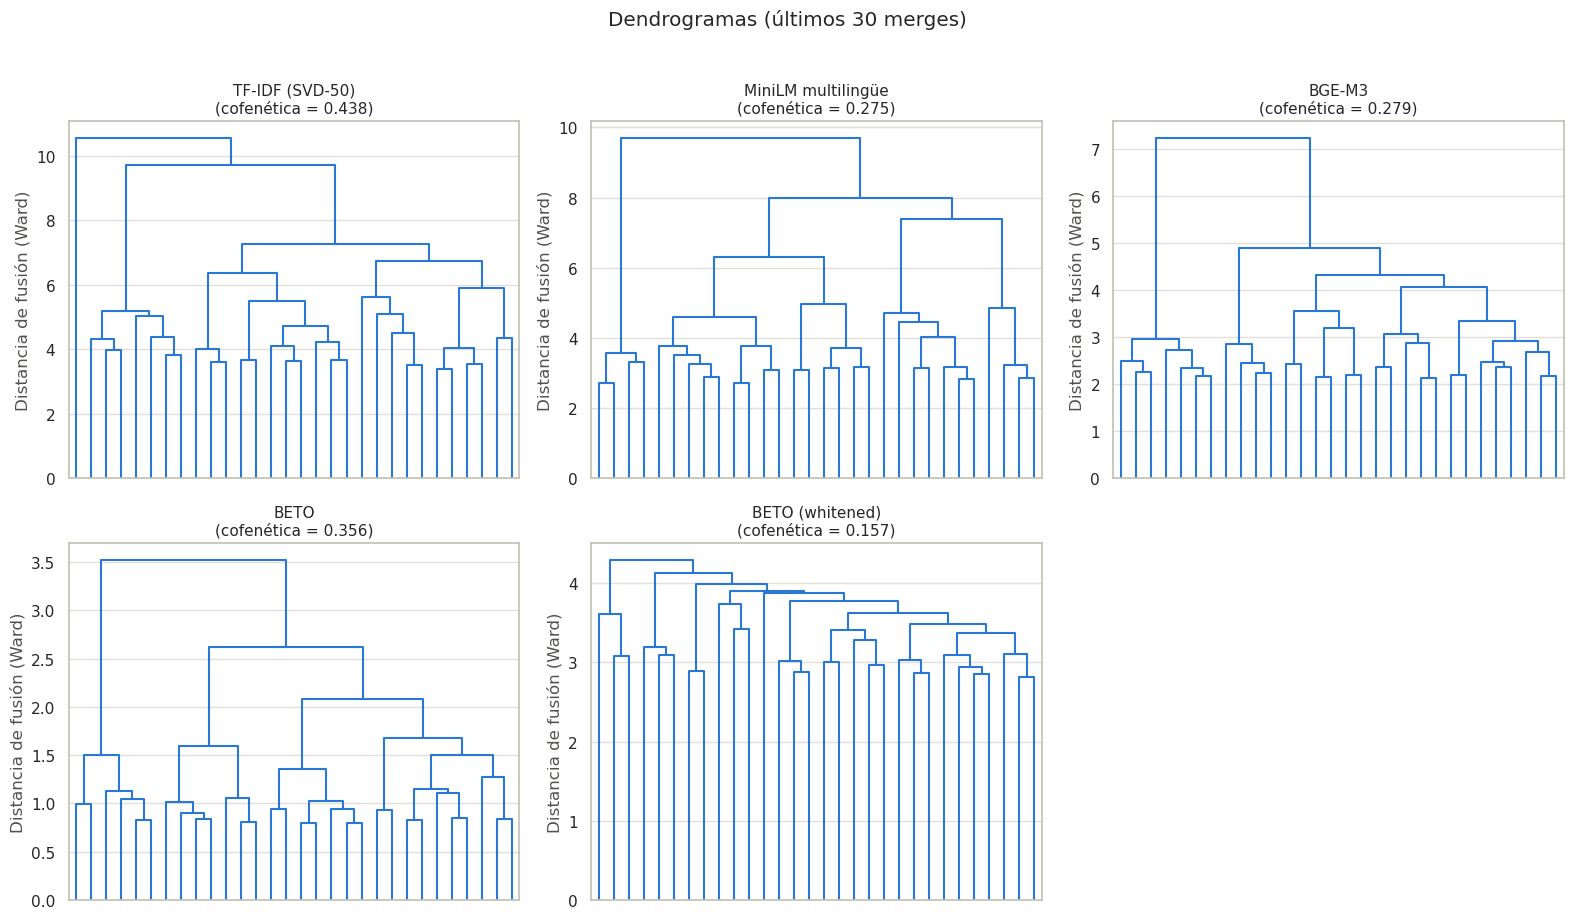

In [6]:
fig, axes = rejilla(len(embeddings))
for ax, (nombre, Z) in zip(axes, linkages.items()):
    dendrogram(Z, truncate_mode="lastp", p=30, ax=ax, no_labels=True,
               color_threshold=0, above_threshold_color="#2a78d6")
    ax.set_title(f"{nombre}\n(cofenética = {cofeneticas[nombre]:.3f})", fontsize=11)
    ax.set_ylabel("Distancia de fusión (Ward)")
    ax.set_xticks([])
plt.suptitle("Dendrogramas (últimos 30 merges)", y=1.02)
plt.tight_layout()
plt.show()


## Métricas no supervisadas por número de clústeres

Para cada técnica se corta el dendrograma en k = 2…15 y se calculan silhouette
(con distancia coseno), Calinski-Harabasz y Davies-Bouldin.

In [7]:
from sklearn.metrics import (calinski_harabasz_score, davies_bouldin_score,
                             silhouette_score)

RANGO_K = range(2, 16)
filas = []
etiquetas_por_k = {}
for nombre, emb in embeddings.items():
    Z = linkages[nombre]
    for k in RANGO_K:
        etiquetas = fcluster(Z, t=k, criterion="maxclust")
        etiquetas_por_k[(nombre, k)] = etiquetas
        filas.append({
            "tecnica": nombre,
            "k": k,
            "silhouette": silhouette_score(emb, etiquetas, metric="cosine"),
            "calinski_harabasz": calinski_harabasz_score(emb, etiquetas),
            "davies_bouldin": davies_bouldin_score(emb, etiquetas),
        })

metricas = pd.DataFrame(filas)
metricas.head()


,tecnica,k,silhouette,calinski_harabasz,davies_bouldin
0,TF-IDF (SVD-50),2,0.166708,73.053467,1.505325
1,TF-IDF (SVD-50),3,0.126956,70.336307,2.976634
2,TF-IDF (SVD-50),4,0.098279,60.384104,4.098509
3,TF-IDF (SVD-50),5,0.104292,54.393897,3.854032
4,TF-IDF (SVD-50),6,0.086055,50.215205,3.786576


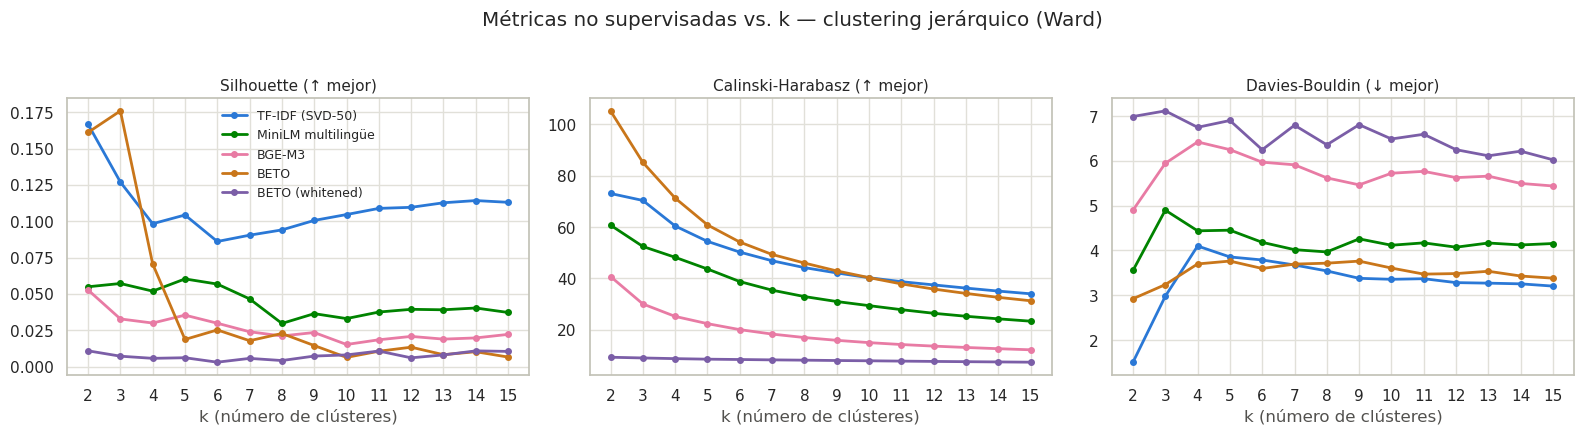

In [8]:
COLORES_TEC = dict(zip(embeddings, PALETA))
config_metricas = [("silhouette", "Silhouette (↑ mejor)"),
                   ("calinski_harabasz", "Calinski-Harabasz (↑ mejor)"),
                   ("davies_bouldin", "Davies-Bouldin (↓ mejor)")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, (col, titulo) in zip(axes, config_metricas):
    for nombre in embeddings:
        serie = metricas[metricas["tecnica"] == nombre]
        ax.plot(serie["k"], serie[col], marker="o", markersize=4, linewidth=2,
                color=COLORES_TEC[nombre], label=nombre)
    ax.set_xlabel("k (número de clústeres)")
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks(list(RANGO_K))
axes[0].legend(frameon=False, fontsize=9)
plt.suptitle("Métricas no supervisadas vs. k — clustering jerárquico (Ward)", y=1.03)
plt.tight_layout()
plt.show()


## Resumen: mejor k por técnica

Se elige el k que maximiza silhouette y se reportan las tres métricas en ese corte,
junto con el tamaño de los clústeres resultantes.

In [9]:
mejores = (metricas.loc[metricas.groupby("tecnica")["silhouette"].idxmax()]
           .set_index("tecnica").round(3))
mejores["cofenetica"] = pd.Series(cofeneticas).round(3)
mejores


,k,silhouette,calinski_harabasz,davies_bouldin,cofenetica
tecnica,,,,,
BETO,3,0.176,85.167,3.237,0.356
BETO (whitened),2,0.011,9.249,6.988,0.157
BGE-M3,2,0.053,40.696,4.898,0.279
MiniLM multilingüe,5,0.060,43.629,4.451,0.275
TF-IDF (SVD-50),2,0.167,73.053,1.505,0.438


In [10]:
for nombre in embeddings:
    k = int(mejores.loc[nombre, "k"])
    tam = np.bincount(etiquetas_por_k[(nombre, k)])[1:].tolist()
    print(f"{nombre} (k={k}): tamaños de clúster = {sorted(tam, reverse=True)}")


TF-IDF (SVD-50) (k=2): tamaños de clúster = [1439, 73]
MiniLM multilingüe (k=5): tamaños de clúster = [381, 374, 273, 255, 229]
BGE-M3 (k=2): tamaños de clúster = [1194, 318]
BETO (k=3): tamaños de clúster = [1026, 309, 177]
BETO (whitened) (k=2): tamaños de clúster = [1385, 127]


## ¿Los clústeres separan por tema o por longitud del artículo?

BETO es la única técnica que **no ve un texto truncado**: las demás cortan a 2,000
caracteres, mientras que el chunking recorre el artículo completo y promedia los vectores
de chunk. Ese promedio introduce una dependencia mecánica con la longitud — un artículo de
un chunk conserva su vector; uno de cinco chunks queda cerca del centroide del corpus,
simplemente por promediar más. Si el clustering se apoya en eso, el silhouette sube sin
que la partición sea temática.

Se mide con **η²**: la fracción de la varianza de la longitud del artículo que explica la
partición en clústeres. η² alto significa que saber el clúster predice la longitud, es
decir, que los clústeres están ordenados por tamaño de artículo. Se acompaña de un test de
Kruskal-Wallis (no paramétrico, la longitud es muy asimétrica) y se calcula para **todas**
las técnicas, para que el valor de BETO se lea contra una línea base y no en el vacío.


In [11]:
from scipy.stats import kruskal

longitudes = muestra["texto_norm"].str.len().to_numpy()


def eta_cuadrado(valores: np.ndarray, grupos: np.ndarray) -> float:
    """Fracción de la varianza de `valores` explicada por la partición `grupos`."""
    media = valores.mean()
    ss_entre = sum(
        (grupos == g).sum() * (valores[grupos == g].mean() - media) ** 2
        for g in np.unique(grupos)
    )
    return ss_entre / ((valores - media) ** 2).sum()


filas = []
for nombre in embeddings:
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    por_cluster = [longitudes[etiquetas == c] for c in np.unique(etiquetas)]
    medianas = [np.median(g) for g in por_cluster]
    filas.append({
        "tecnica": nombre,
        "k": k,
        "eta2_longitud": round(eta_cuadrado(longitudes, etiquetas), 3),
        "p_kruskal": f"{kruskal(*por_cluster).pvalue:.1e}",
        "silhouette": mejores.loc[nombre, "silhouette"],
        # Rango de medianas entre clústeres: cuánto se separan en caracteres.
        "mediana_min": int(min(medianas)),
        "mediana_max": int(max(medianas)),
    })

efecto_longitud = pd.DataFrame(filas).set_index("tecnica")
efecto_longitud


,k,eta2_longitud,p_kruskal,silhouette,mediana_min,mediana_max
tecnica,,,,,,
TF-IDF (SVD-50),2,0.021,7.2e-16,0.167,383,1670
MiniLM multilingüe,5,0.034,5.0e-09,0.060,1290,2032
BGE-M3,2,0.015,9.5e-05,0.053,1309,1710
BETO,3,0.180,1.0e-98,0.176,259,1996
BETO (whitened),2,0.013,3.6e-05,0.011,1187,1664


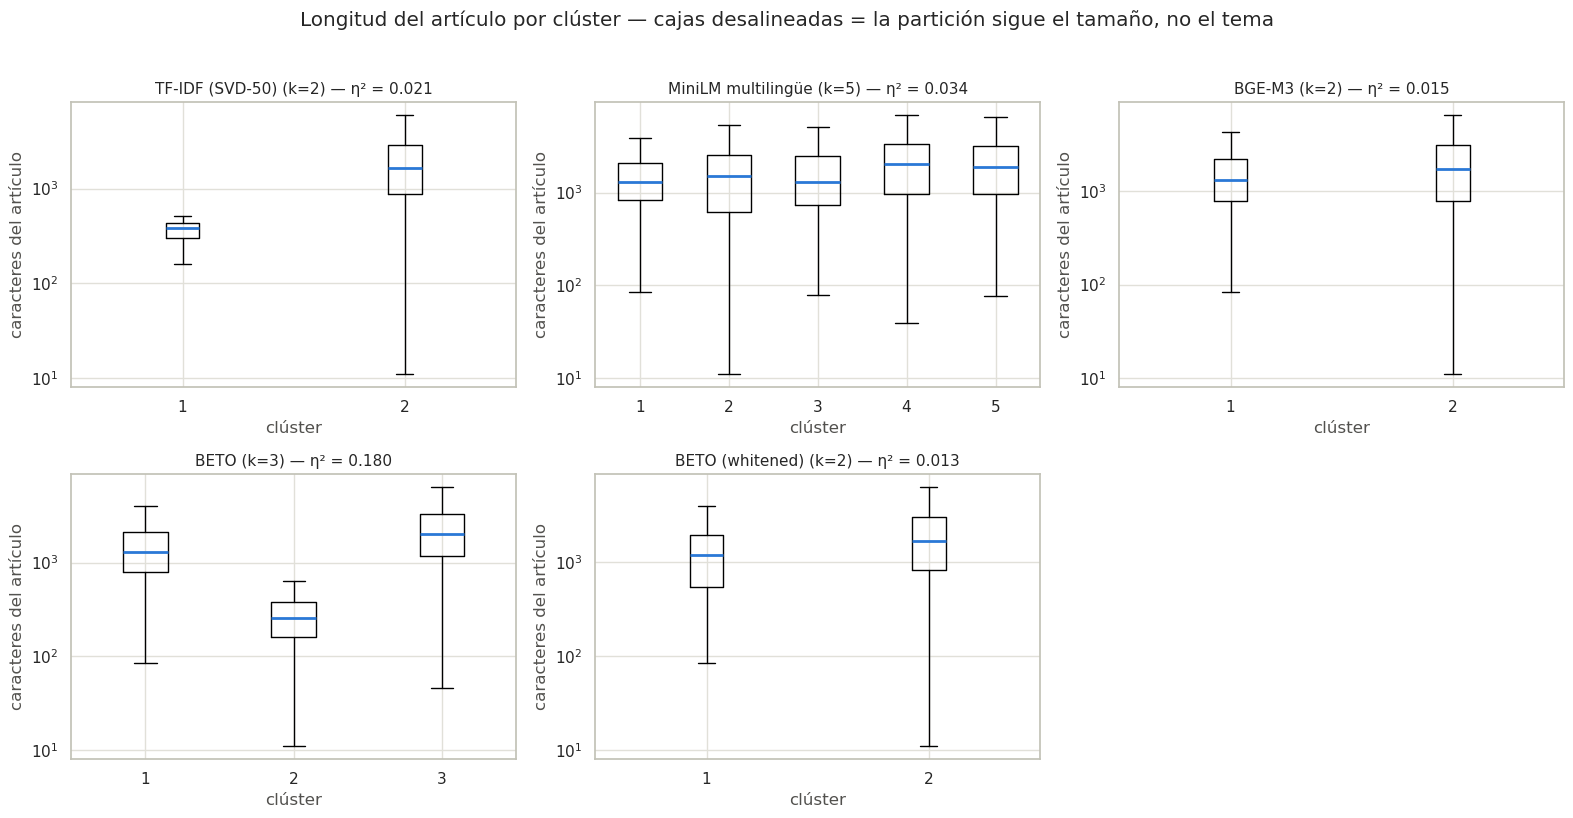

In [12]:
fig, axes = rejilla(len(embeddings), alto=4.0)
for ax, nombre in zip(axes, embeddings):
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    ax.boxplot([longitudes[etiquetas == c] for c in range(1, k + 1)],
               showfliers=False, medianprops={"color": "#2a78d6", "linewidth": 2})
    ax.set_yscale("log")
    ax.set_title(f"{nombre} (k={k}) — η² = {efecto_longitud.loc[nombre, 'eta2_longitud']:.3f}",
                 fontsize=11)
    ax.set_xlabel("clúster")
    ax.set_ylabel("caracteres del artículo")
plt.suptitle("Longitud del artículo por clúster — cajas desalineadas = la partición sigue el tamaño, no el tema",
             y=1.02)
plt.tight_layout()
plt.show()


### Cómo leer esta sección

El eje y está en escala logarítmica porque la longitud de los artículos abarca varios
órdenes de magnitud. La lectura es directa:

- **Cajas alineadas entre clústeres (η² bajo, ~0.0–0.05)** — la partición es indiferente a
  la longitud; el silhouette que obtenga esa técnica se debe a otra cosa (idealmente, tema).
- **Cajas escalonadas (η² alto, > 0.2)** — los clústeres están ordenados por tamaño de
  artículo. Un silhouette alto en ese escenario **no acredita calidad temática**: separar
  textos largos de cortos es una partición fácil y muy compacta en el espacio.

El contraste decisivo es **BETO vs. BETO (whitened)** contra las tres técnicas truncadas.
Si BETO muestra η² netamente mayor que las demás, su ventaja en silhouette es un artefacto
del promediado de chunks, y la comparación de técnicas debe apoyarse en las métricas
supervisadas (ARI/AMI contra sección) más que en el silhouette. Si η² es comparable al de
las demás, la afirmación queda descartada y el silhouette de BETO sí es interpretable.

Este contraste **debe leerse de la ejecución**, no darse por sabido: sin correr estas
celdas la conclusión no está respaldada.


## Métricas supervisadas por número de clústeres (sección como label)

Se usa la sección del artículo (`seccion`) como etiqueta de referencia externa y se
evalúan los cortes k = 2…15 con ARI, AMI, homogeneidad, completitud y V-measure.
Las secciones son muy granulares (cientos de valores distintos entre periódicos),
por lo que se privilegian las métricas ajustadas por azar (ARI, AMI), que no
premian la mera fragmentación.

In [13]:
from sklearn.metrics import (adjusted_mutual_info_score, adjusted_rand_score,
                             completeness_score, homogeneity_score, v_measure_score)

secciones = muestra["seccion"].fillna("(sin sección)").to_numpy()
print(f"Secciones distintas en la submuestra: {pd.Series(secciones).nunique()}")

filas = []
for nombre in embeddings:
    for k in RANGO_K:
        etiquetas = etiquetas_por_k[(nombre, k)]
        filas.append({
            "tecnica": nombre,
            "k": k,
            "ari": adjusted_rand_score(secciones, etiquetas),
            "ami": adjusted_mutual_info_score(secciones, etiquetas),
            "homogeneidad": homogeneity_score(secciones, etiquetas),
            "completitud": completeness_score(secciones, etiquetas),
            "v_measure": v_measure_score(secciones, etiquetas),
        })

metricas_sup = pd.DataFrame(filas)
metricas_sup.head()

Secciones distintas en la submuestra: 213


,tecnica,k,ari,ami,homogeneidad,completitud,v_measure
0,TF-IDF (SVD-50),2,-0.001439,0.013005,0.016311,0.317938,0.031030
1,TF-IDF (SVD-50),3,0.019336,0.117388,0.093724,0.533439,0.159436
2,TF-IDF (SVD-50),4,0.054026,0.163079,0.147962,0.467537,0.224785
3,TF-IDF (SVD-50),5,0.073060,0.182358,0.177050,0.454719,0.254865
4,TF-IDF (SVD-50),6,0.097834,0.199468,0.203829,0.449603,0.280495


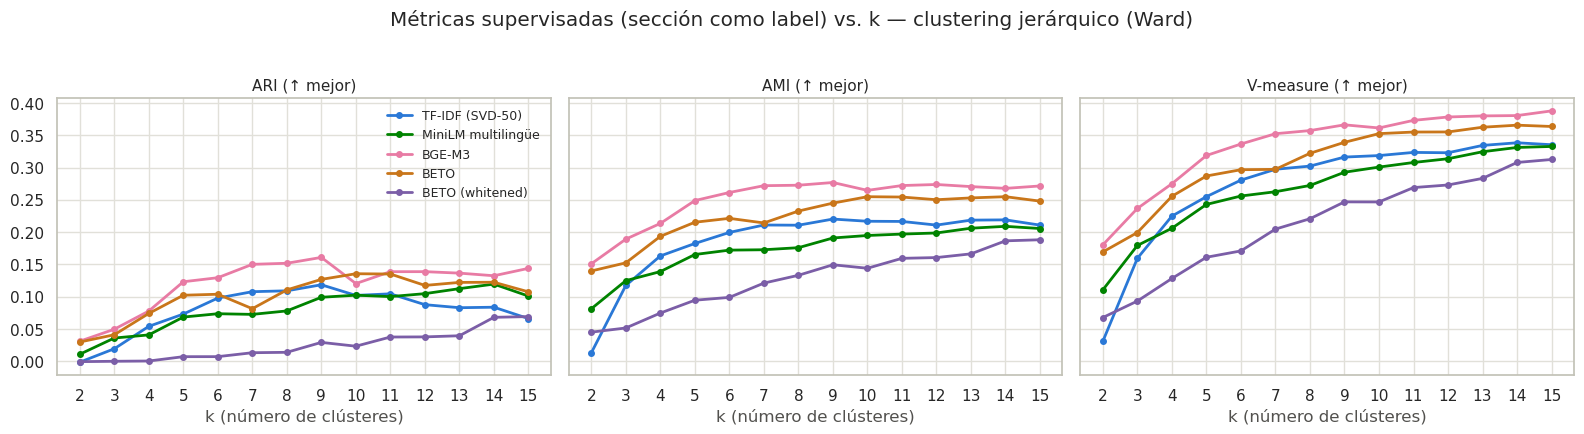

Métricas supervisadas en el k óptimo (por silhouette) de cada técnica:


,k,ari,ami,homogeneidad,completitud,v_measure
tecnica,,,,,,
TF-IDF (SVD-50),2,-0.001,0.013,0.016,0.318,0.031
MiniLM multilingüe,5,0.068,0.165,0.173,0.410,0.243
BGE-M3,2,0.031,0.151,0.102,0.751,0.180
BETO,3,0.041,0.152,0.122,0.548,0.199
BETO (whitened),2,-0.001,0.045,0.036,0.477,0.068


In [14]:
config_sup = [("ari", "ARI (↑ mejor)"), ("ami", "AMI (↑ mejor)"),
              ("v_measure", "V-measure (↑ mejor)")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, (col, titulo) in zip(axes, config_sup):
    for nombre in embeddings:
        serie = metricas_sup[metricas_sup["tecnica"] == nombre]
        ax.plot(serie["k"], serie[col], marker="o", markersize=4, linewidth=2,
                color=COLORES_TEC[nombre], label=nombre)
    ax.set_xlabel("k (número de clústeres)")
    ax.set_title(titulo, fontsize=11)
    ax.set_xticks(list(RANGO_K))
axes[0].legend(frameon=False, fontsize=9)
plt.suptitle("Métricas supervisadas (sección como label) vs. k — clustering jerárquico (Ward)", y=1.03)
plt.tight_layout()
plt.show()

resumen_sup = (metricas_sup.merge(mejores.reset_index()[["tecnica", "k"]].astype({"k": int}),
                                  on=["tecnica", "k"])
               .set_index("tecnica").round(3))
print("Métricas supervisadas en el k óptimo (por silhouette) de cada técnica:")
resumen_sup

## Árboles completos coloreados por el corte óptimo

Dendrograma **completo** (las 1,512 hojas) de cada técnica. La línea punteada marca la
altura de corte que produce el mejor k según silhouette; las ramas por debajo de esa
altura se colorean por clúster resultante.

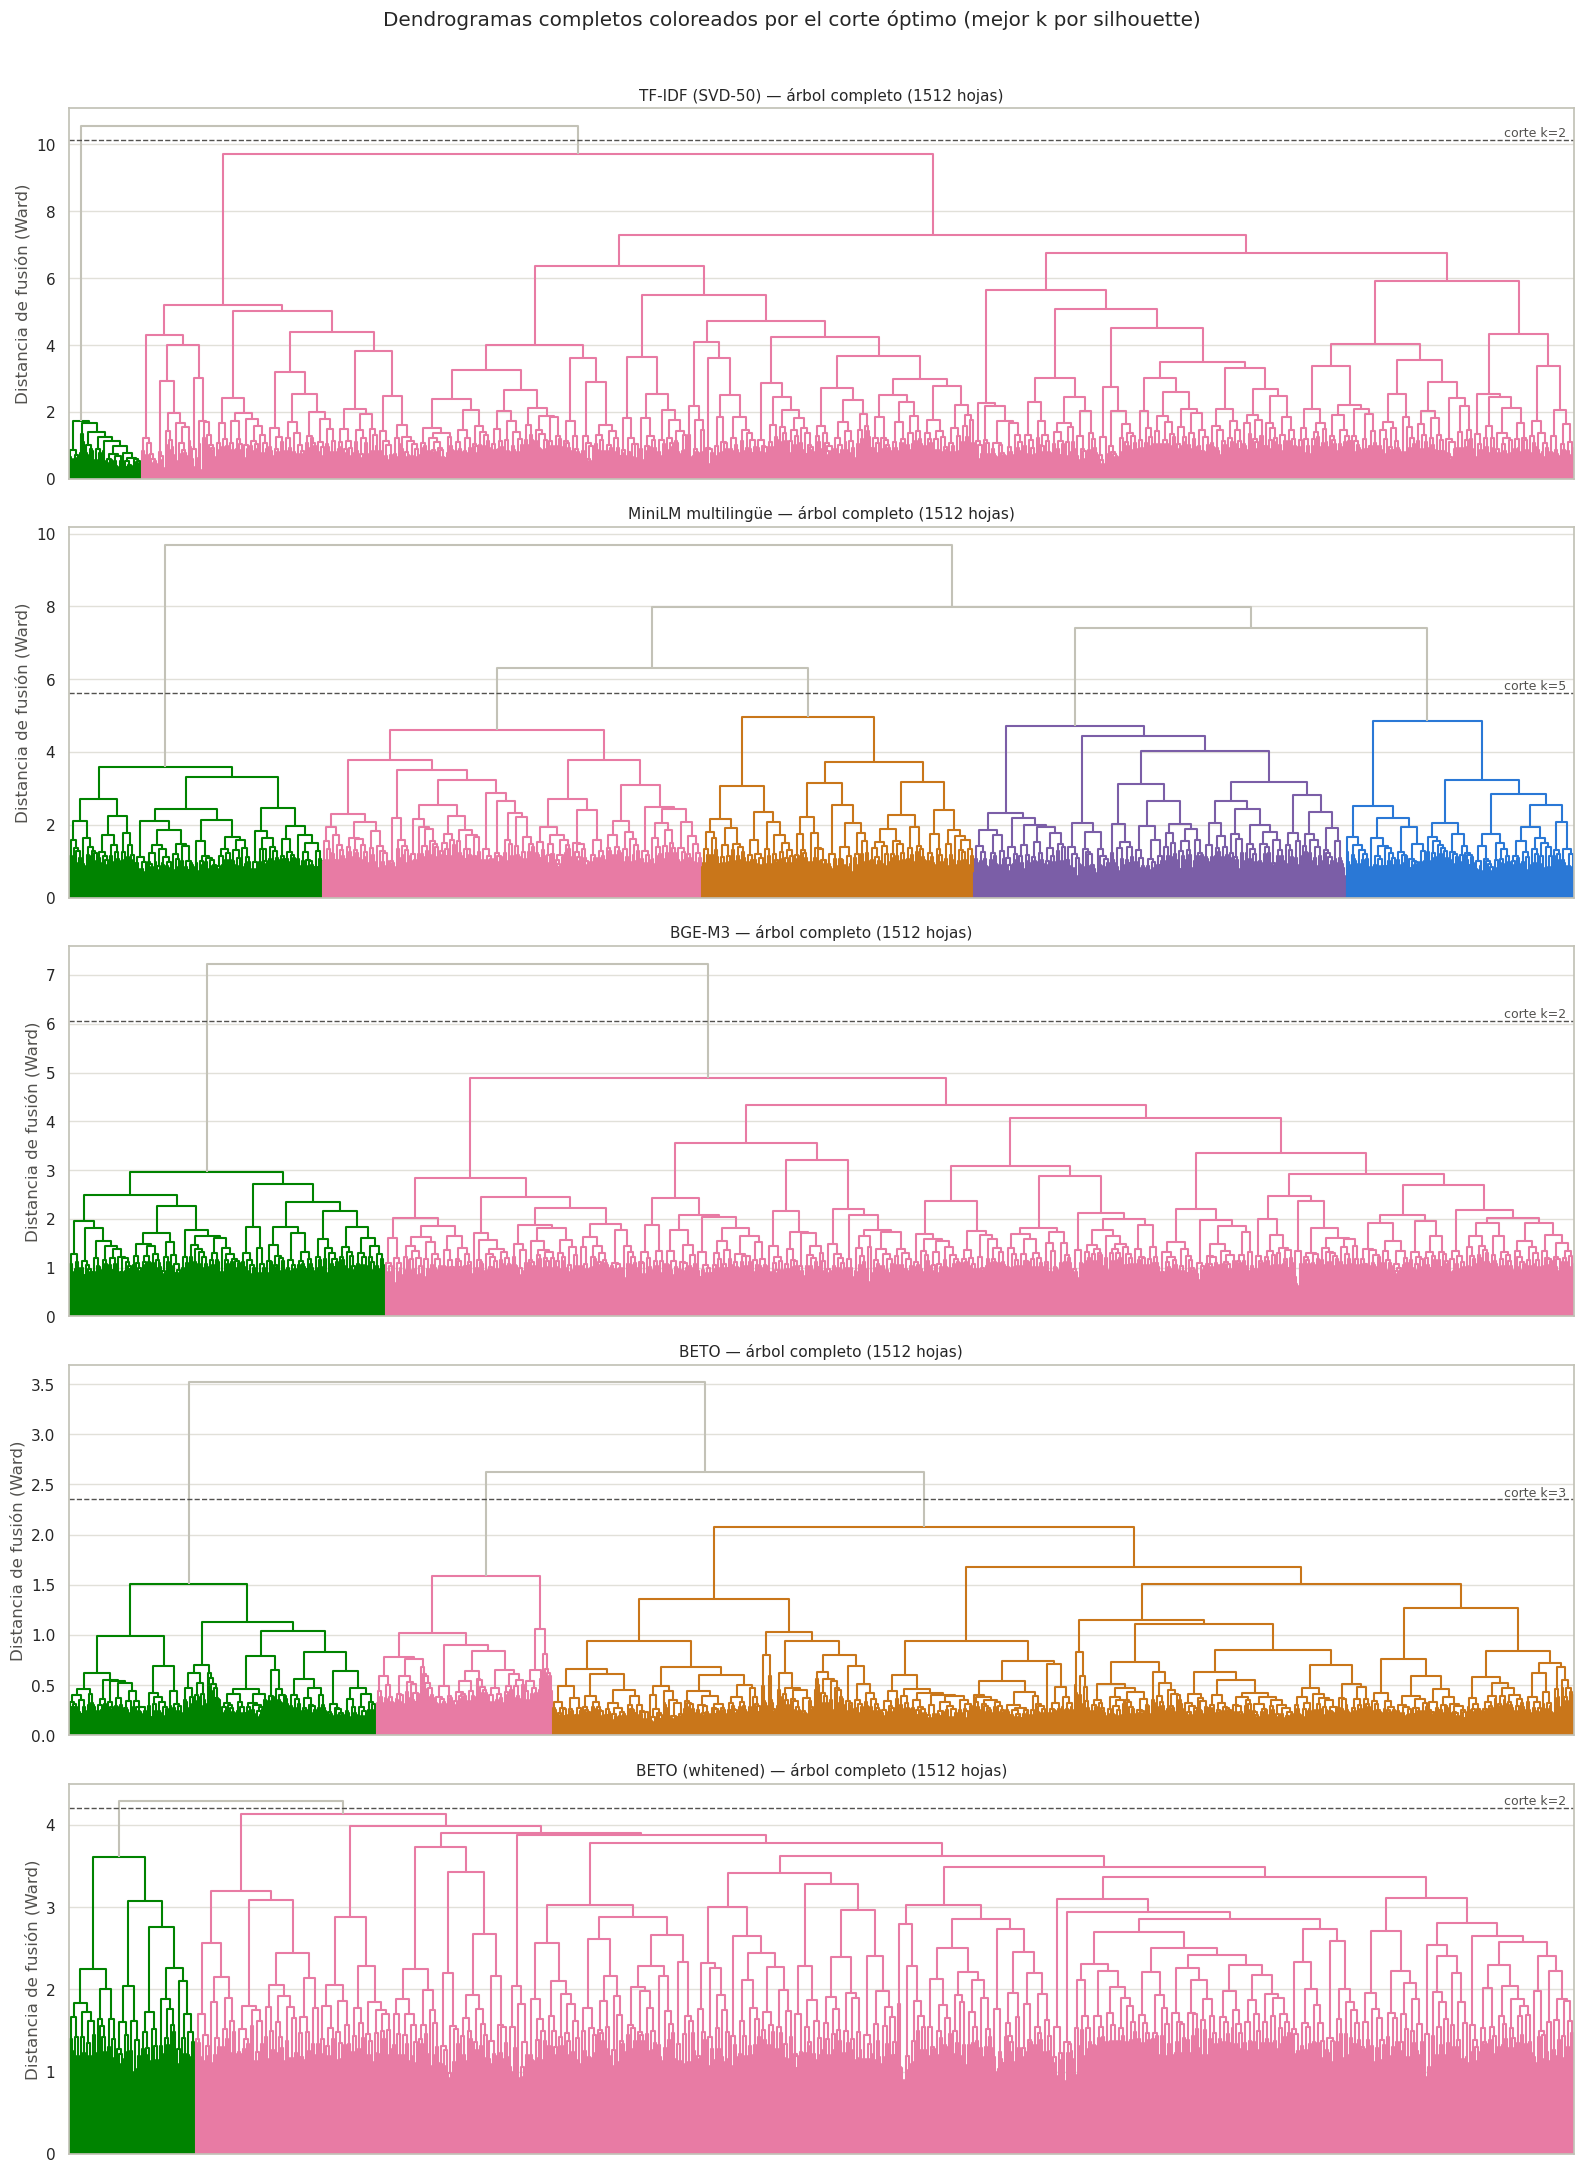

In [15]:
fig, axes = plt.subplots(len(embeddings), 1, figsize=(16, 4.3 * len(embeddings)))
for ax, (nombre, Z) in zip(axes, linkages.items()):
    k = int(mejores.loc[nombre, "k"])
    # Altura de corte: punto medio entre los merges que dejan k y k-1 clústeres
    umbral = (Z[-k, 2] + Z[-(k - 1), 2]) / 2 if k > 1 else Z[-1, 2] * 1.05
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=umbral,
               above_threshold_color="#c3c2b7")
    ax.axhline(umbral, color="#52514e", linestyle="--", linewidth=1)
    ax.text(0.995, umbral, f" corte k={k}", transform=ax.get_yaxis_transform(),
            ha="right", va="bottom", fontsize=9, color="#52514e")
    ax.set_title(f"{nombre} — árbol completo ({Z.shape[0] + 1} hojas)", fontsize=11)
    ax.set_ylabel("Distancia de fusión (Ward)")
    ax.set_xticks([])
plt.suptitle("Dendrogramas completos coloreados por el corte óptimo (mejor k por silhouette)", y=1.01)
plt.tight_layout()
plt.show()


## Visualización de los cortes óptimos (t-SNE)

Proyección t-SNE 2D (misma receta del EDA: reducción previa a 50 dims) coloreada por el
clúster jerárquico en el mejor k de cada técnica.

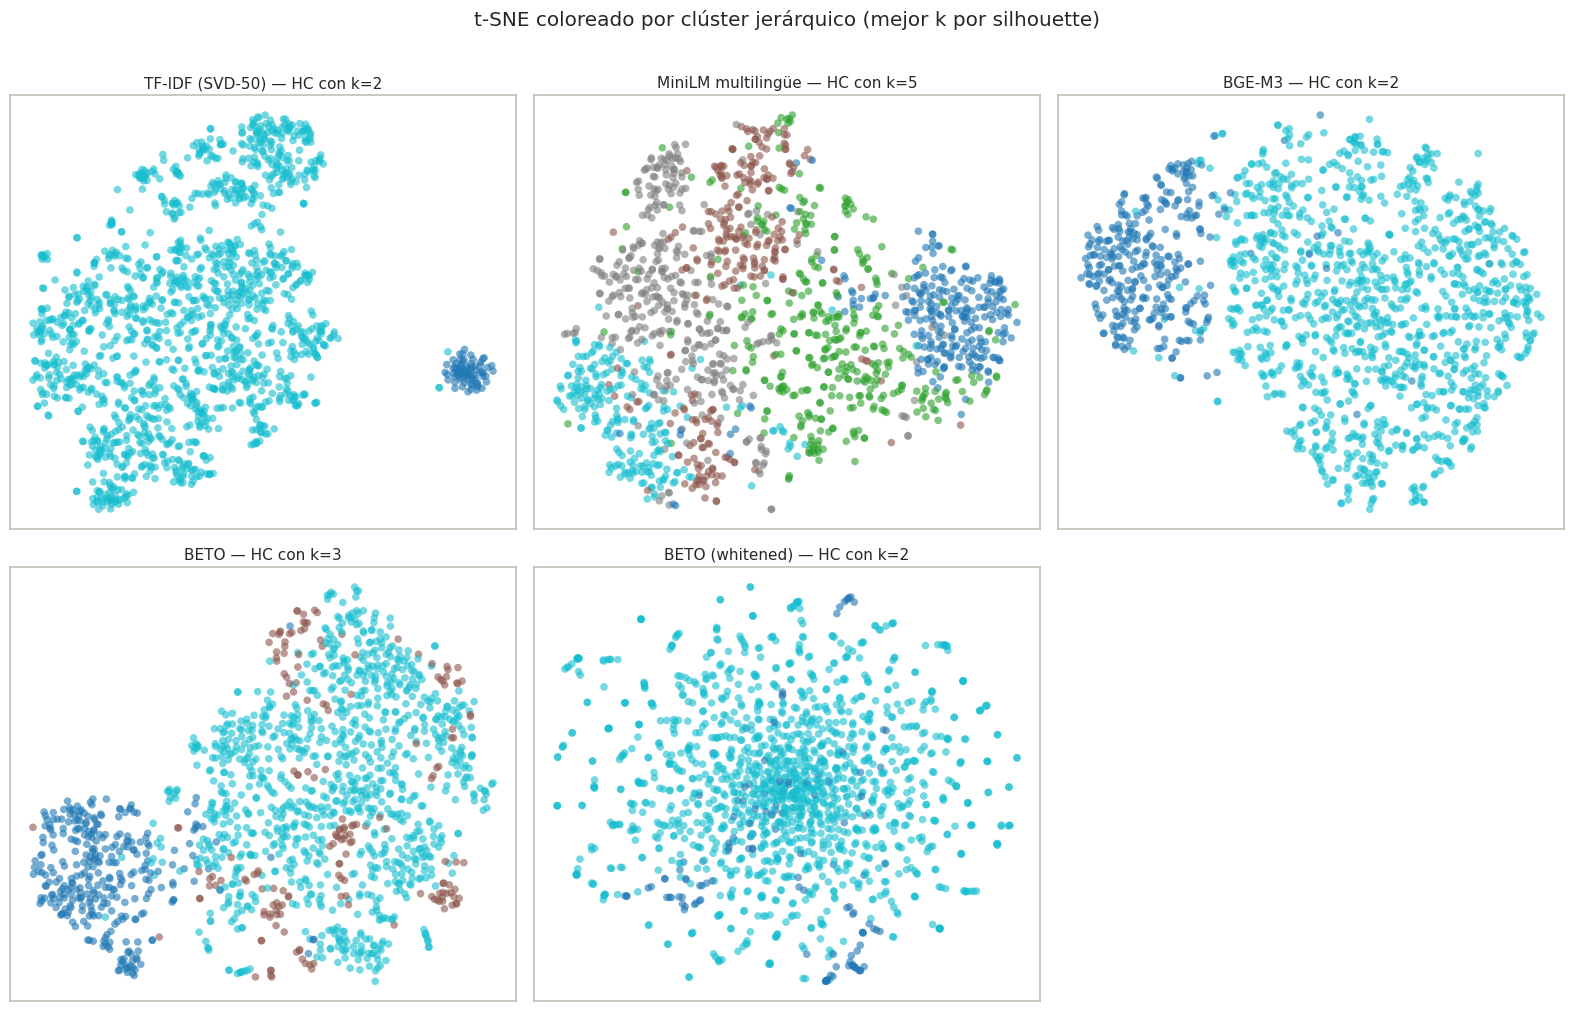

In [16]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

fig, axes = rejilla(len(embeddings), alto=5)
for ax, (nombre, emb) in zip(axes, embeddings.items()):
    x50 = emb if emb.shape[1] <= 50 else PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(emb)
    xy = TSNE(n_components=2, init="pca", perplexity=30, max_iter=1000,
              random_state=RANDOM_STATE).fit_transform(x50)
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    ax.scatter(xy[:, 0], xy[:, 1], c=etiquetas, cmap="tab10", s=30, alpha=0.6, linewidths=0)
    ax.set_title(f"{nombre} — HC con k={k}", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("t-SNE coloreado por clúster jerárquico (mejor k por silhouette)", y=1.01)
plt.tight_layout()
plt.show()


## Títulos descriptivos por clúster (DeepSeek vía vLLM)

Para cada clúster del corte óptimo se toma una **muestra aleatoria de 10 artículos**
(título + inicio del texto) y se pide a `deepseek-ai/DeepSeek-V4-Flash` (servidor H200,
cliente de `src/llm_clients`) un **título descriptivo corto** del tema dominante.
**Requiere VPN GlobalProtect activa.**

Nota: DeepSeek es un modelo de razonamiento — consume parte del presupuesto de
`max_tokens` en el campo `reasoning` antes de emitir `content`, por eso se usa un
límite generoso aunque la respuesta esperada sea corta.

In [17]:
from src.llm_clients import get_chat_client, load_config

config = load_config()
cliente_chat = get_chat_client(config)
N_EJEMPLOS = 10

PROMPT_TITULO = (
    "Eres un analista de prensa ecuatoriana. A continuación tienes una muestra de "
    "artículos (título y primeras líneas) que pertenecen a un mismo clúster temático "
    "obtenido por clustering no supervisado.\n\n{ejemplos}\n\n"
    "Escribe UN solo título descriptivo en español (máximo 10 palabras) que resuma el "
    "tema dominante del clúster. Si los temas son heterogéneos, dilo en el título "
    "(p. ej. 'Actualidad general: política, deportes y sucesos'). "
    "Responde únicamente con el título, sin comillas ni explicaciones."
)


def titular_cluster(indices: np.ndarray) -> str:
    """Pide a DeepSeek un título descriptivo para los artículos indicados."""
    ejemplos = "\n".join(
        f"- {muestra.loc[i, 'titulo'] or '(sin título)'}: "
        f"{muestra.loc[i, 'texto_norm'][:200]}…"
        for i in indices
    )
    respuesta = cliente_chat.chat.completions.create(
        model=config.chat_model,
        messages=[{"role": "user", "content": PROMPT_TITULO.format(ejemplos=ejemplos)}],
        temperature=0.3,
        max_tokens=2000,  # modelo de razonamiento: reserva presupuesto para 'reasoning'
    )
    contenido = respuesta.choices[0].message.content
    return contenido.strip().strip('"') if contenido else "(respuesta vacía)"


In [18]:
from tqdm.auto import tqdm

rng = np.random.default_rng(RANDOM_STATE)
filas = []
for nombre in embeddings:
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    for c in tqdm(range(1, k + 1), desc=f"{nombre} (k={k})"):
        indices = np.flatnonzero(etiquetas == c)
        seleccion = rng.choice(indices, size=min(N_EJEMPLOS, len(indices)), replace=False)
        filas.append({
            "tecnica": nombre,
            "cluster": c,
            "n_articulos": len(indices),
            "titulo_deepseek": titular_cluster(seleccion),
            "ejemplos": " | ".join(muestra.loc[seleccion[:3], "titulo"].fillna("(sin título)")),
        })

titulos_clusters = pd.DataFrame(filas)
with pd.option_context("display.max_colwidth", 120):
    display(titulos_clusters)


TF-IDF (SVD-50) (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

MiniLM multilingüe (k=5):   0%|          | 0/5 [00:00<?, ?it/s]

BGE-M3 (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

BETO (k=3):   0%|          | 0/3 [00:00<?, ?it/s]

BETO (whitened) (k=2):   0%|          | 0/2 [00:00<?, ?it/s]

,tecnica,cluster,n_articulos,titulo_deepseek,ejemplos
0,TF-IDF (SVD-50),1,73,"Actualidad general: política, deportes, economía y sociedad","Un terre­moto de 4,4 gra­dos sacude Milán | AZÚCAR | ECUADOR."
1,TF-IDF (SVD-50),2,1439,"Actualidad diversa: política, deportes, salud y sucesos",Asamblea Define Fecha Para La Comparecencia | Otro Oficio Imposible | Gremio Médico: “No Somos Mafiosos”
2,MiniLM multilingüe,1,255,Actualidad deportiva y sucesos,"Cevallos: 'Dida' Domínguez Es El ""Mejor Arquero De La Historia Del Fútbol Ecuatoriano"" | Citizens Vencen Y No Afloja..."
3,MiniLM multilingüe,2,381,"Actualidad general: deportes, política, clima y sucesos",Guayaquil City Sería El Rival De Barcelona Sc En La Noche Amarilla 2026 | Campamento Militar Temporal Fue Incendiado...
4,MiniLM multilingüe,3,273,"Actualidad ecuatoriana: sucesos, política, clima y servicios","Regreso A Clases En Quito: Horarios De Expresos Escolares Y Operativos De Seguridad | ""¿Qué Hacía Un Adolescente De ..."
5,MiniLM multilingüe,4,374,"Actualidad ecuatoriana: economía, política, salud y sociedad",Los Ecuatorianos Financian Sus Emergencias Con Sus Familias Y Amigos | El Agua De Güitig Dará El Salto A España Tras...
6,MiniLM multilingüe,5,229,"Corrupción, justicia y seguridad en Ecuador",Ley de aborto: el plazo de apro­ba­ción queda corto | El Fin Del Estado | Recuperar El Control De Las Cárceles
7,BGE-M3,1,318,"Deportes variados: ciclismo, fútbol y otros","Primoz Roglic Corrió La Etapa 4 Del Tour ""Disfrazado"" De Momia | Kendry Páez Viajará A Entrenar Con El Chelsea Luego..."
8,BGE-M3,2,1194,"Actualidad heterogénea: política, sucesos y cultura","Al Menos 36 Muertos En Una Estampida De Nueva Delhi, India | ‘The Power Of The Dog’ Arrasa En Los Premios Critics Ch..."
9,BETO,1,309,"Actualidad deportiva variada: fútbol, boxeo y más","Dt Rescalvo Deja Atrás Dos Partidos Sin Ganar Y Dice Que Emelec No Se Rendirá | Senegal, Sin Copa Y En Conflicto | B..."


### Lectura de los títulos

Los títulos generados permiten interpretar cualitativamente cada corte: en los cortes
desbalanceados (TF-IDF y BGE-M3 con k=2) se espera un clúster pequeño con tema nítido y
uno grande de "actualidad general"; en MiniLM (k=5) los títulos deberían reflejar
particiones temáticas más específicas.

## Análisis de subclusters

Cada clúster del corte óptimo con al menos `MIN_SUBCLUSTER` artículos se subdivide con
un nuevo linkage de Ward sobre sus miembros — equivalente al subárbol del dendrograma
global bajo la altura de corte, ya que por debajo de ella los merges de Ward solo
involucran puntos del mismo clúster. El número de subclusters se elige en 2…6
maximizando silhouette (coseno) **dentro** del clúster; los clústeres con menos
artículos que el mínimo se dejan sin subdividir.

In [19]:
MIN_SUBCLUSTER = 40
RANGO_SUB_K = range(2, 7)

subclusters = {}  # (tecnica, cluster) -> (indices globales, etiquetas de subcluster)
filas = []
for nombre, emb in embeddings.items():
    k = int(mejores.loc[nombre, "k"])
    etiquetas = etiquetas_por_k[(nombre, k)]
    for c in range(1, k + 1):
        indices = np.flatnonzero(etiquetas == c)
        if len(indices) < MIN_SUBCLUSTER:
            print(f"{nombre} — clúster {c}: {len(indices)} artículos, no se subdivide")
            continue
        Z_sub = linkage(emb[indices], method="ward")
        mejor_sil, mejor_sub = -np.inf, None
        for sub_k in RANGO_SUB_K:
            etiquetas_sub = fcluster(Z_sub, t=sub_k, criterion="maxclust")
            sil = silhouette_score(emb[indices], etiquetas_sub, metric="cosine")
            if sil > mejor_sil:
                mejor_sil, mejor_sub = sil, etiquetas_sub
        subclusters[(nombre, c)] = (indices, mejor_sub)
        filas.append({
            "tecnica": nombre,
            "cluster": c,
            "n_articulos": len(indices),
            "sub_k": int(mejor_sub.max()),
            "silhouette_sub": round(mejor_sil, 3),
            "tamanios_sub": sorted(np.bincount(mejor_sub)[1:].tolist(), reverse=True),
        })

resumen_subclusters = pd.DataFrame(filas)
resumen_subclusters

,tecnica,cluster,n_articulos,sub_k,silhouette_sub,tamanios_sub
0,TF-IDF (SVD-50),1,73,5,0.207,"[48, 11, 9, 3, 2]"
1,TF-IDF (SVD-50),2,1439,2,0.098,"[1159, 280]"
2,MiniLM multilingüe,1,255,2,0.129,"[188, 67]"
3,MiniLM multilingüe,2,381,2,0.055,"[213, 168]"
4,MiniLM multilingüe,3,273,2,0.115,"[180, 93]"
5,MiniLM multilingüe,4,374,6,0.080,"[93, 81, 70, 62, 44, 24]"
6,MiniLM multilingüe,5,229,2,0.137,"[148, 81]"
7,BGE-M3,1,318,3,0.046,"[173, 120, 25]"
8,BGE-M3,2,1194,4,0.022,"[416, 276, 254, 248]"
9,BETO,1,309,2,0.101,"[194, 115]"


### Títulos descriptivos por subcluster (DeepSeek vía vLLM)

Se reutiliza `titular_cluster` para pedir a DeepSeek un título por subcluster (misma
muestra aleatoria de hasta 10 artículos). La tabla incluye el título del clúster padre
para leer la jerarquía temática completa. **Requiere VPN GlobalProtect activa.**

In [20]:
filas = []
for (nombre, c), (indices, etiquetas_sub) in subclusters.items():
    titulo_padre = titulos_clusters.query(
        "tecnica == @nombre and cluster == @c")["titulo_deepseek"].iloc[0]
    for s in tqdm(range(1, int(etiquetas_sub.max()) + 1), desc=f"{nombre} — clúster {c}"):
        indices_sub = indices[etiquetas_sub == s]
        seleccion = rng.choice(indices_sub, size=min(N_EJEMPLOS, len(indices_sub)), replace=False)
        filas.append({
            "tecnica": nombre,
            "cluster": c,
            "titulo_cluster": titulo_padre,
            "subcluster": s,
            "n_articulos": len(indices_sub),
            "titulo_deepseek": titular_cluster(seleccion),
            "ejemplos": " | ".join(muestra.loc[seleccion[:3], "titulo"].fillna("(sin título)")),
        })

titulos_subclusters = pd.DataFrame(filas)
with pd.option_context("display.max_colwidth", 100):
    display(titulos_subclusters)

TF-IDF (SVD-50) — clúster 1:   0%|          | 0/5 [00:00<?, ?it/s]

TF-IDF (SVD-50) — clúster 2:   0%|          | 0/2 [00:00<?, ?it/s]

MiniLM multilingüe — clúster 1:   0%|          | 0/2 [00:00<?, ?it/s]

MiniLM multilingüe — clúster 2:   0%|          | 0/2 [00:00<?, ?it/s]

MiniLM multilingüe — clúster 3:   0%|          | 0/2 [00:00<?, ?it/s]

...

BETO — clúster 2:   0%|          | 0/2 [00:00<?, ?it/s]

BETO — clúster 3:   0%|          | 0/2 [00:00<?, ?it/s]

BETO (whitened) — clúster 1:   0%|          | 0/4 [00:00<?, ?it/s]

BETO (whitened) — clúster 2:   0%|          | 0/2 [00:00<?, ?it/s]

,tecnica,cluster,titulo_cluster,subcluster,n_articulos,titulo_deepseek,ejemplos
0,TF-IDF (SVD-50),1,"Actualidad general: política, deportes, economía y sociedad",1,11,"Actualidad variada: política, economía y sociedad",TRÁNSITO\r\nEl riesgo de cir­cu­lar y acci­den­tarse | Sus accio­nes fue­ron sus­pen­di­das | Su...
1,TF-IDF (SVD-50),1,"Actualidad general: política, deportes, economía y sociedad",2,2,Emelec y polémica por uso de VAR,CON DUDAS | Polé­mica por la roja a Cabeza
2,TF-IDF (SVD-50),1,"Actualidad general: política, deportes, economía y sociedad",3,3,Actualidad general: deportes y pasatiempos,PALABRAS ESCONDIDAS | INGLATERRA. El City gana y el Uni­ted iguala | ⯈ ROMA. La Lazio derrotó al...
3,TF-IDF (SVD-50),1,"Actualidad general: política, deportes, economía y sociedad",4,9,"Actualidad general: deportes, cultura, política y ciencia",ECUADOR. | UN ENSAMBLE CON 17 RITMOS | Empre­sa­rio en minas y petró­leos
4,TF-IDF (SVD-50),1,"Actualidad general: política, deportes, economía y sociedad",5,48,"Actualidad variada: política, deportes, inseguridad y sociedad","VOCES | Ley de aborto: el plazo de apro­ba­ción queda corto | Xavier Arreaga, par­ti­dazo y susto"
5,TF-IDF (SVD-50),2,"Actualidad diversa: política, deportes, salud y sucesos",1,280,Actualidad general: deportes y sucesos,"Rusia No Participará En Los Juegos Olímpicos Ni En El Mundial De Catar 2022 | Buques Foráneos, E..."
6,TF-IDF (SVD-50),2,"Actualidad diversa: política, deportes, salud y sucesos",2,1159,"Actualidad variada: política, sucesos y sociedad",Biólogo Lleva Un Mes Desaparecido Luego De Viajar A Palmar | ‘Offshore’ De Antonio Peré Ocultó S...
7,MiniLM multilingüe,1,Actualidad deportiva y sucesos,1,67,"Actualidad general: política, deportes y sucesos",Willian Termina Su Contrato Con Corinthians | 'Muerte En Berruecos': La Búsqueda Del Asesino De ...
8,MiniLM multilingüe,1,Actualidad deportiva y sucesos,2,188,"Deportes: fútbol, atletismo e hípica","Citizens Vencen Y No Aflojan Los Primeros Puestos | Gallardo, El Terror De Boca | Con Gol De Eri..."
9,MiniLM multilingüe,2,"Actualidad general: deportes, política, clima y sucesos",1,213,"Temas heterogéneos: política, historia, sociedad y actualidad",Israel Reconoce Ataque Al Líbano | Pedro Palacios: ‘Trabajamos En Sentar Las Bases Para Desarrol...


### Lectura de los subclusters

Los subclusters revelan la estructura temática interna de cada clúster: en los clústeres
grandes y heterogéneos (tipo "actualidad general") los títulos de los subclusters
deberían separar temas más específicos (política, deportes, economía, sucesos). Un
subcluster cuyo título repite el del clúster padre sugiere que el tema ya era homogéneo
y la subdivisión aporta poco; valores bajos de `silhouette_sub` apuntan en la misma
dirección.

## Lectura de resultados

- La **correlación cofenética** indica qué tan fielmente el árbol de Ward representa las
  distancias originales de cada espacio de embeddings.
- Los valores absolutos de silhouette suelen ser bajos en corpus de prensa (los temas se
  solapan); lo relevante es la **comparación relativa entre técnicas** y la forma de las
  curvas (codos o mesetas sugieren un rango razonable de k).
- Calinski-Harabasz no es directamente comparable **entre** técnicas (depende de la escala
  del espacio); úsese solo para comparar valores de k dentro de una misma técnica.
- **BETO** es un BERT de propósito general sin fine-tuning de similitud (a diferencia de
  MiniLM y BGE-M3, entrenados con objetivos contrastivos de oraciones). Su espacio es
  notoriamente **anisotrópico**: las similitudes coseno entre documentos arbitrarios se
  concentran en valores altos (~0.95), lo que comprime el rango de distancias y suele
  perjudicar al silhouette. Comparar **BETO** con **BETO (whitened)** aísla ese efecto: si
  el whitening mejora las métricas, el cuello de botella era la geometría del espacio y no
  el chunking ni el pooling. Si no las mejora, la limitación está en la representación
  misma, y el camino sería fine-tuning contrastivo del modelo, no más post-proceso.
- Antes de premiar a BETO por un silhouette alto, revisar el **η² de longitud**: BETO es la
  única técnica que promedia chunks sobre el artículo completo, y ese promediado puede
  ordenar los clústeres por tamaño de texto en lugar de por tema. Un η² netamente mayor que
  el de las técnicas truncadas indicaría que la ventaja es un artefacto y que la decisión
  debe apoyarse en ARI/AMI contra sección.
- Este resultado alimenta la decisión del método de embedding definitivo para el pipeline
  de clustering + RAG con Milvus (ver conclusiones del EDA).
